## Setup

In [8]:
import yaml
import pathlib
import pickle as pk
import warnings

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier

import utils
from data import MET_Data, get_transformation_function

In [2]:
old_format_maps = {"T": ["logcpm"], "E": ["pca-ipfx"], "M": ["arbors"]}

def train_classifiers(encoder, classifiers, met_data, train_ids, test_ids, forms, trans_funcs, type_map, count_thresh):
    num_train = len(train_ids)
    joint_ids = np.concatenate([train_ids, test_ids])
    joint_data = met_data.get_specimens(joint_ids, outputs = list(forms) + ["cluster_label"])
    joint_transformed = {form: trans_funcs.get(form, lambda x: x)(joint_data[form]) for form in forms}
    joint_tensors = {form: torch.from_numpy(array).float() for (form, array) in joint_transformed.items()}
    joint_z = encoder(joint_tensors)[0].numpy(force = True)
    
    joint_types = type_map(np.char.strip(joint_data["cluster_label"]))
    (train_types, test_types) = np.split(joint_types, [num_train])
    (labels, counts) = np.unique(train_types, return_counts = True)
    train_mask = np.isin(train_types, labels[counts > count_thresh])
    train_y = train_types[train_mask]
    test_mask = np.isin(test_types, train_y)
    test_y = test_types[test_mask]
    (train_z, test_z) = (joint_z[:num_train][train_mask], joint_z[num_train:][test_mask])
    
    scores = [model.fit(train_z, train_y).score(test_z, test_y) for model in classifiers]
    return scores

def get_experiment_accuracies(exps, met_data, specimen_ids, trans_funcs, mappers, count_thresh = 6):
    (accs, control) = ({}, {})
    for (exp_name, exp_dict) in exps.items():
        (accs[exp_name], control_accs) = ({}, {})
        for (i, fold) in exp_dict["folds"].items():
            train_ids = specimen_ids[np.isin(np.char.strip(specimen_ids), np.char.strip(fold["train_ids"]))]
            test_ids = specimen_ids[~np.isin(np.char.strip(specimen_ids), np.char.strip(fold["train_ids"]))]
            for modal in exp_dict["config"]["modalities"]:
                encoder = fold["best"][modal]["enc"]
                modal_accs = accs[exp_name].setdefault(modal, {})
                forms = exp_dict["config"]["formats"][modal] if "formats" in exp_dict["config"] else old_format_maps[modal]
                print(f"Generating {exp_name} - {i}: {modal} -> T-type             ", end = "\r")
                for (map_id, map_func) in mappers.items():
                    qda = QDA(reg_param=1e-2, store_covariance=True)
                    classifiers = [qda] if control else [qda, DummyClassifier()]
                    scores = train_classifiers(encoder, classifiers, met_data, train_ids, test_ids, forms, 
                                               trans_funcs, map_func, count_thresh)
                    modal_accs.setdefault(map_id, []).append(scores[0])
                    if not control:
                        control_accs.setdefault(modal, {}).setdefault(map_id, []).append(scores[1])
        control = control_accs if not control else control
    print("\nComplete                                                       ")
    return (accs, control)

def get_experiment_latent(exp_name, exp_dict, met_data, specimen_ids, trans_funcs, valid_modalities = []):
    valid_modalities = exp_dict["config"]["modalities"] if valid_modalities is None else valid_modalities
    modalities = set(valid_modalities) & set(exp_dict["config"]["modalities"])
    fold_latents = []
    folds = exp_dict["folds"]
    folds = dict(enumerate(folds, 1)) if type(folds) == list else folds
    for (i, fold) in folds.items():
        fold_latent = {}
        non_train_ids = specimen_ids[~np.isin(np.char.strip(specimen_ids), np.char.strip(fold["train_ids"]))]
        model = fold["best"] if "best" in fold else fold["model"].models
        for in_modal in modalities:
            for out_modal in modalities:
                if "formats" in exp_dict["config"]:
                    (in_formats, out_formats) = (exp_dict["config"]["formats"][in_modal], exp_dict["config"]["formats"][out_modal])
                else:
                    (in_formats, out_formats) = (old_format_maps[in_modal], old_format_maps[out_modal])
                valid_data = met_data.query(non_train_ids, formats = [tuple(in_formats + out_formats)], 
                                            outputs = list(in_formats) + ["specimen_id"])
                if len(valid_data[in_formats[0]]):
                    print(f"Generating {exp_name} - {i}: {in_modal} -> {out_modal}             ", end = "\r")
                    transformed = {form: trans_funcs.get(form, lambda x: x)(valid_data[form]) for form in in_formats}
                    input_data = {form: torch.from_numpy(array).float() for (form, array) in transformed.items()}
                    latent = model.infer(input_data, in_modal, [out_modal], sample = False)[out_modal][0].numpy(force = True)
                    fold_latent.setdefault(in_modal, {})[out_modal] = (latent, valid_data["specimen_id"])
        fold_latents.append(fold_latent)
    return fold_latents

def load_experiment(exp_type, base_dir, exp_name, checkpoints = False):
    exp_path = pathlib.Path(base_dir) / exp_name
    if exp_type == "cca":
        experiment = utils.load_pca_cca(exp_path)
    elif exp_type == "coupler":
        experiment = utils.load_coupler_folds(exp_path, get_checkpoints = checkpoints)
    elif exp_type == "autoencoder":
        experiment = utils.load_jit_folds(exp_path, get_checkpoints = checkpoints)
    else:
        raise ValueError(f'Experiment type "{exp_type}" not recognized.')
    return experiment

def generate_plan(specified, targets):
    plan = {}
    if not specified:
        spec_targets = list(targets.keys())
    else:
        spec_targets = [tupl[0] for tupl in specified]
    for target in spec_targets:
        plan[target] = {}
        spec_groups = [tupl[1] for tupl in specified if tupl[0] == target and tupl[1] is not None]
        if not spec_groups:
            spec_groups = targets[target]["groups"]
        for group in spec_groups:
            spec_experiments = [tupl[2] for tupl in specified 
                                if tupl[0] == target and tupl[1] == group and tupl[2] is not None]
            if not spec_experiments:
                spec_experiments = list(all_experiments[group].keys())
            plan[target][group] = spec_experiments
    return plan

def run_latent_plan(plan, targets, met_data, loaded_experiments, previous = {}):
    for (target, groups_dict) in plan.items():
        print(f"\nRunning target {target}:")
        target_info = targets[target]
        specimen_ids = sample_data(met_data, target_info["queries"])
        trans_funcs = {form: get_transformation_function(params) for (form, params) in target_info["transform"].items()}
        target_latent = previous.setdefault(target, {})
        for (group, experiments) in groups_dict.items():
            group_latent = target_latent.setdefault(group, {})
            for exp_name in experiments:
                exp_dict = loaded_experiments[group][exp_name]
                group_latent[exp_name] = get_experiment_latent(exp_name, exp_dict, met_data, specimen_ids, 
                                                               trans_funcs, target_info["modalities"])
        print("\nComplete                                                       ")
    return previous

def compute_scores(reconstruction_accs):
    scores = {}
    for (target, target_dict) in reconstruction_accs.items():
        scores[target] = {}
        for (group, group_dict) in target_dict.items():
            scores[target][group] = {}
            for (exp_name, folds) in group_dict.items():
                modal_strings = [key for fold_dict in folds for key in fold_dict.keys()]
                means = {string: np.mean([fold[string] for fold in folds]) for string in modal_strings}
                stds = {string: np.std([fold[string] for fold in folds]) for string in modal_strings}
                scores[target][group][exp_name] = {"mean": means, "std": stds}
    return scores

def build_table(scores, column_info, groups, num_decimals, exps = None):
    (column_means, column_stds) = ({}, {})
    for (modal_string, target, col_label) in column_info:
        (column_means[col_label], column_stds[col_label]) = ({}, {})
        target_metrics = {exp_name:metrics for (group, group_dict) in scores[target].items() 
                         for (exp_name, metrics) in group_dict.items() if group in groups}
        column_means[col_label] = {exp_name: exp_dict["mean"].get(modal_string) 
                                   for (exp_name, exp_dict) in target_metrics.items()}
        column_stds[col_label] = {exp_name: exp_dict["std"].get(modal_string) 
                                  for (exp_name, exp_dict) in target_metrics.items()}
    mean_frame = pd.DataFrame(column_means).round(num_decimals).astype("string").fillna("--")
    std_frame = pd.DataFrame(column_stds).round(num_decimals).astype("string").fillna("")
    combined_frame = mean_frame + ("±" + std_frame).replace("±", "")
    combined_frame = combined_frame[~(combined_frame == "--").all(1)]
    if exps:
        combined_frame = combined_frame[combined_frame.index.isin(exps)]
        sorted_frame = combined_frame.sort_index(key = lambda series: series.map(lambda exp_name: exps.index(exp_name)))
    else:
        sorted_frame = combined_frame.sort_index(key = lambda series: series.map(lambda exp_name: groups.index(exp_name.split("-")[-1])))
    return sorted_frame

def generate_2d_plot(exp_dict, fold, met, exps = [], data_map = []):
    pca_dict = {}
    for (exp_name, folds) in exp_dict.items():
        all_latent = [latent for out_dict in folds[fold].values() for (latent, _) in out_dict.values()]
        pca_dict[exp_name] = PCA(2).fit(np.concatenate(all_latent))
    plot_data = {"Experiment": [], "Input Modal": [], "Output Modal": [], "X": [], "Y": []}
    exps = exp_dict.keys() if not exps else exps
    for (exp_name, folds) in exp_dict.items():
        if exp_name in exps:
            for (in_modal, out_dict) in folds[fold].items():
                for (out_modal, (latent, specimens)) in out_dict.items():
                    proj_latent = pca_dict[exp_name].transform(latent)
                    cell_data = met.get_specimens(specimens)
                    plot_data["Experiment"].extend([exp_name]*specimens.size)
                    plot_data["Input Modal"].extend([in_modal]*specimens.size)
                    plot_data["Output Modal"].extend([out_modal]*specimens.size)
                    plot_data["X"].extend(proj_latent[:, 0].tolist())
                    plot_data["Y"].extend(proj_latent[:, 1].tolist())
                    for (name, _, func) in data_map:
                        if func is not None:
                            plot_data.setdefault(name, []).extend(func(cell_data).tolist())
                            
    plot = sns.relplot(plot_data, 
                       **{"x": "X", "y": "Y", "col": "Input Modal", "row": "Output Modal", 
                          **{elem: name for (name, elem, _) in data_map}
                         })
    return plot

def sample_data(met_data, queries):
    queries = sorted(queries, key = lambda tupl: tupl[1], reverse = True)
    specimens = []
    for (query, count) in queries:
        if count < 0:
            count = max([array.size for array in specimens])
        elif count == np.inf:
            count = 100000000000000
        specimens.append(met_data.query(**query, outputs = ["specimen_id"])["specimen_id"][:count])
    specimens = np.concatenate(specimens)
    return specimens

## Models

In [3]:
data_paths = {"patchseq": "../data/patchseq.hdf5",
              "EM": "../data/EM.hdf5",
              "smartseq": "../data/smartseq.hdf5",
              "10x": "../data/10x.hdf5",
              "trunc": "../data/patch_smart_trunc.hdf5"}
data_keys = {
    "logcpm": [["patchseq", "logcpm"], ["smartseq", "logcpm_aligned"]], #[["trunc", "logcpm"], ["10x", "logcpm_aligned"]],
    "pca-ipfx": [["patchseq", "pca-ipfx"]],
    "arbors": [["patchseq", "arbors"], ["EM", "arbors"]]}
met_data = MET_Data(data_paths, **data_keys)
for form in ["logcpm", "pca-ipfx", "arbors"]:
    met_data.cache_data(form)

Caching logcpm...
Caching pca-ipfx...
Caching arbors...


In [ ]:
exp_info = {
    "alignment": {
        "type": "autoencoder",
        "dir": "../results/alignment",
        "exps": ["t_patchseq", "t_both", "met_patch", "met_both", "met_full"]},
    "maxweight": {
        "type": "autoencoder",
        "dir": "../results/maxweight",
        "exps": ["t_arm", "e_arm", "m_arm", "t_e", "e_t", "m_e", "e_m", "t_m", "m_t"]},
    "weighted": {
        "type": "autoencoder",
        "dir": "../results/weighted",
        "exps": ["met_et_2x", "met_et_4x", "met_et_4x_10d", "met_et_4x_MET", "met_et_4x_patch"]},
    "vanilla": {
        "type": "autoencoder",
        "dir": "../results/vanilla",
        "exps": ["met_full", "met_full_10d"]},
    "mt": {
        "type": "autoencoder",
        "dir": "../results/mt",
        "exps": ["e_0", "e_05", "e_2", "e_10", "e_100"]},
    "10x": {
        "type": "autoencoder",
        "dir": "../results/10x",
        "exps": ["met_full"]}
}

In [6]:
all_experiments = {group: {f"{exp}-{group}": load_experiment(info["type"], info["dir"], exp) for exp in info["exps"]} 
                   for (group, info) in exp_info.items()}

## Latent Spaces

### General Results

#### Setup

In [6]:
general_targets = {
    "patchseq": {
        "queries": [
            ({"formats": [("logcpm", "pca-ipfx", "arbors")]}, np.inf)],
        "modalities": ["T", "E", "M"],
        "transform": {},
        "groups": {"var", "tight", "loose", "latent", "latentEM", "latentSmart", "slides"},
        "display": {"T": lambda x: 1 - x, "E": lambda x: 1 - x, "M": lambda x: 1 - x}
    },
    "patch+EM": {
        "queries": [
            ({"platforms": ["patchseq"], "formats": [("arbors",)]}, np.inf),
            ({"platforms": ["EM"], "formats": [("arbors",)]}, -1)],
        "modalities": ["M"],
        "transform": {},
        "groups": {"var", "tight", "loose", "latent", "latentEM"},
        "display": {"M": lambda x: 1 - x}
    },
    "patch+smart": {
        "queries": [
            ({"platforms": ["patchseq"], "formats": [("logcpm",)]}, 1000),
            ({"platforms": ["smartseq"], "formats": [("logcpm",)]}, 1000)],
        "modalities": ["T"],
        "transform": {},
        "groups": {"var", "tight", "loose", "latent", "latentSmart"},
        "display": {"T": lambda x: 1 - x}
    }
}

In [7]:
general_latent = {}

In [8]:
specified = [("patch+smart", "alignment", "t_both-alignment")]
# specified = [("patch+EM", "baseline", "met_full-baseline"), ("patch+EM", "baseline", "met-baseline")]
# specified = [("patch+smart", "baseline", "met_full-baseline"), ("patch+smart", "baseline", "met-baseline")]
# specified = [("patchseq", "baseline", None)]
plan = generate_plan(specified, general_targets)
general_latent = run_latent_plan(plan, general_targets, met_data, all_experiments, general_latent)


Running target patch+smart:
Generating t_both-alignment - 10: T -> T             
Complete                                                       


#### Latent Plot

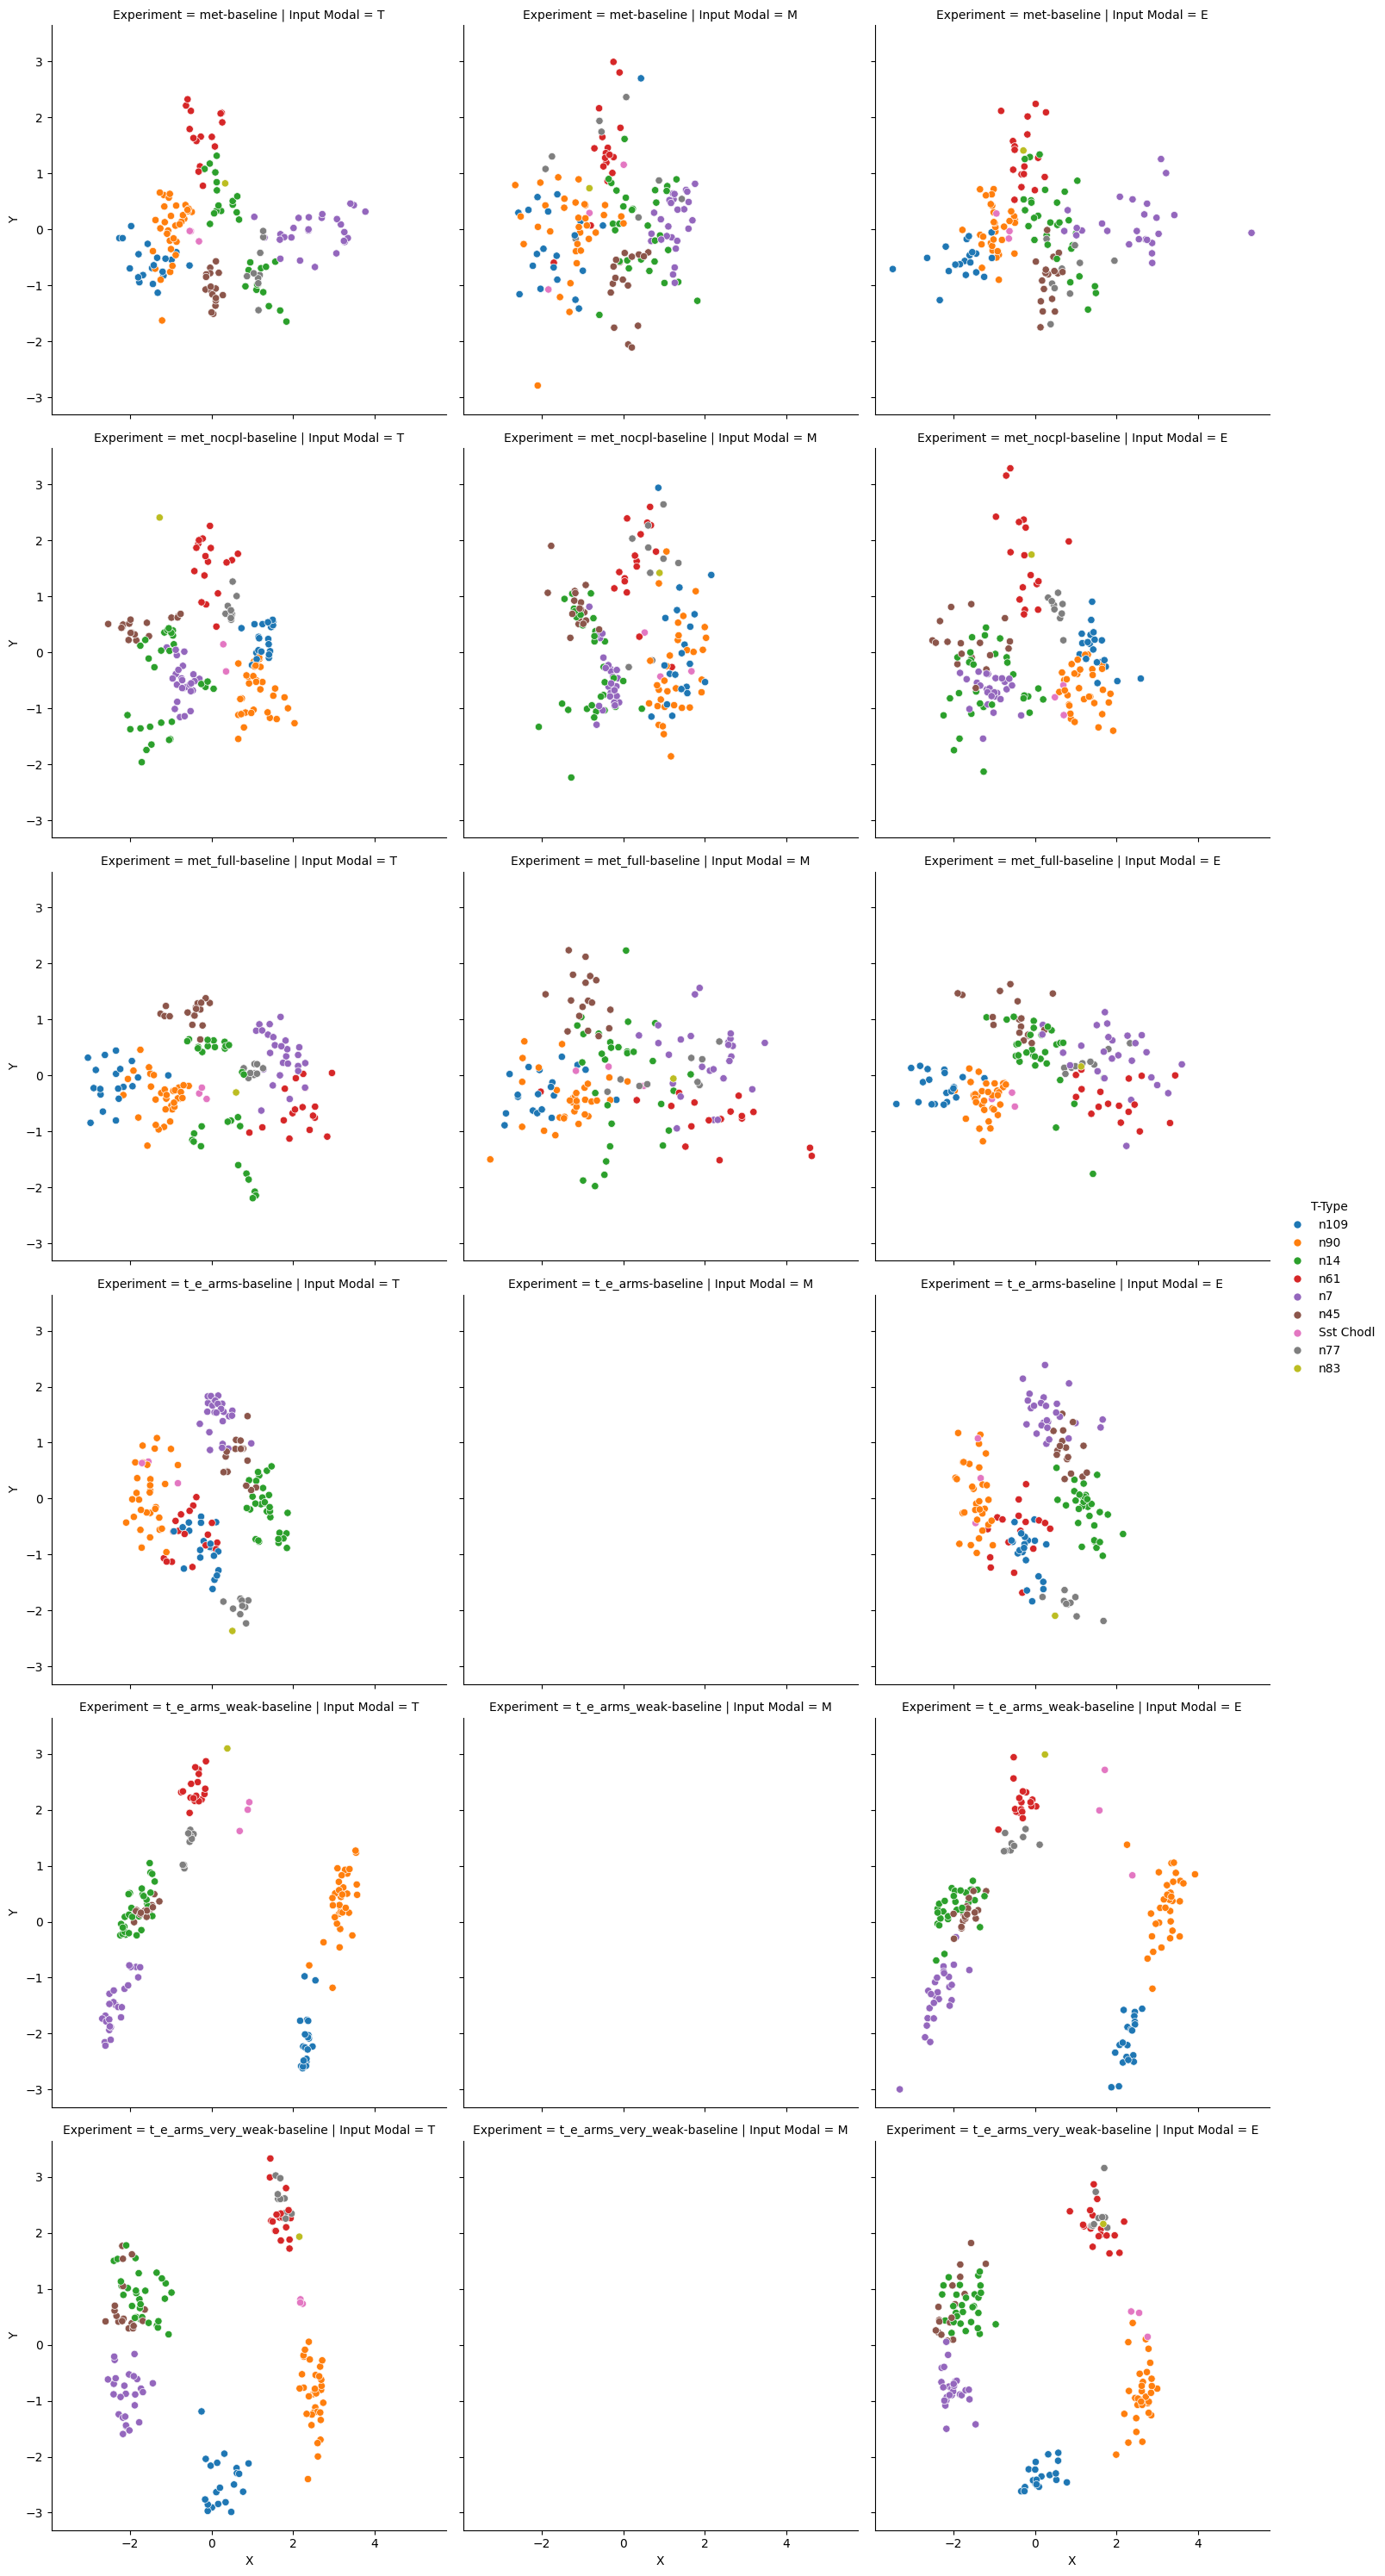

In [10]:
merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n4")
color_func = np.vectorize(lambda elem: merge_map[elem][-10]) 
data_map = {
    ("T-Type", "hue", lambda data: color_func(np.char.strip(data["cluster_label"]))),
    ("Experiment", "row", None)
}
plot = generate_2d_plot(general_latent["patchseq"]["baseline"], 0, met_data, data_map = data_map)
plt.show()

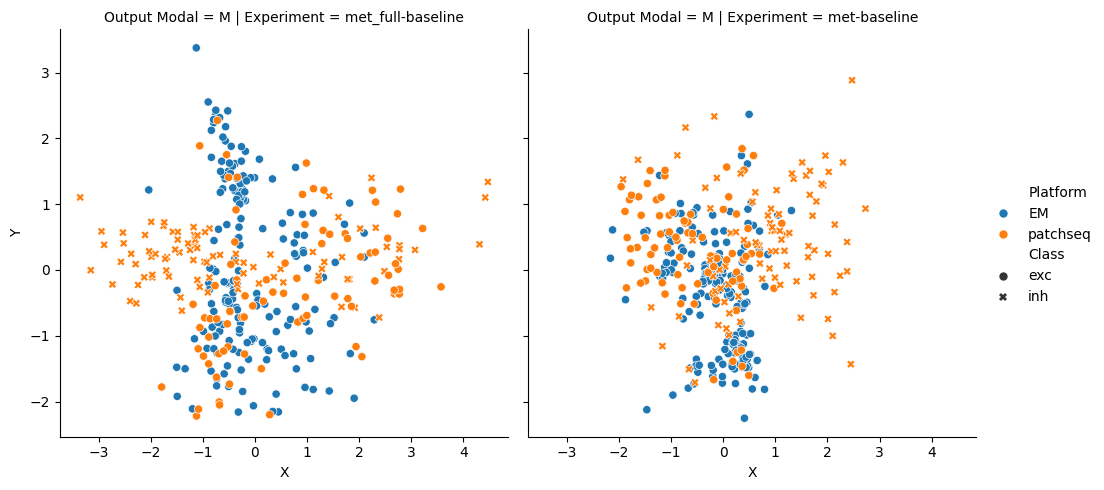

In [14]:
data_map = {
    ("Platform", "hue", lambda data: data["platform"]),
    ("Experiment", "col", None),
    ("Class", "style", lambda data: data["class"])}
plot = generate_2d_plot(
    {**general_latent["patch+EM"]["baseline"]}, 0, met_data, ["met_full-baseline", "met-baseline"],
    data_map)
# plt.savefig("EM_latent.pdf")
plt.show()

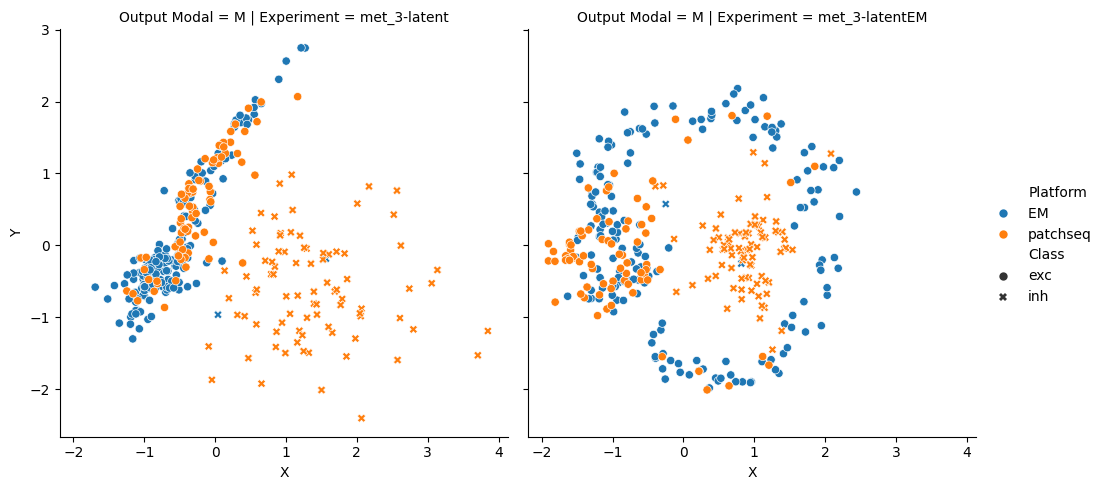

In [ ]:
data_map = {
    ("Platform", "hue", lambda data: data["platform"]),
    ("Experiment", "col", None),
    ("Class", "style", lambda data: data["class"])}
plot = generate_2d_plot(
    {**general_latent["patch+EM"]["baseline"]}, 0, met_data, ["met_full-baseline", "met-baseline"],
    data_map)
# plt.savefig("EM_latent.pdf")
plt.show()

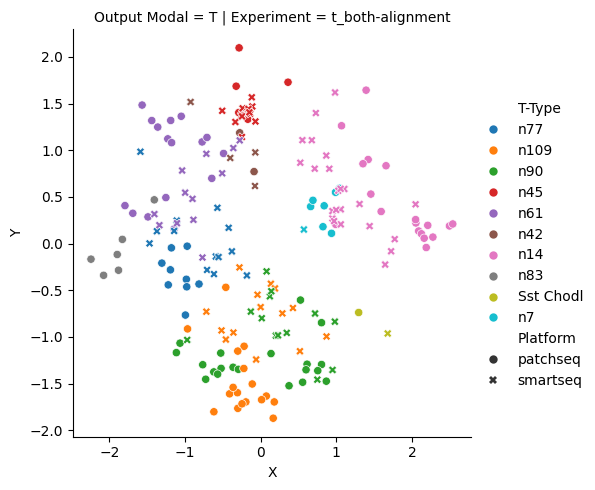

In [9]:
merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n4")
color_func = np.vectorize(lambda elem: merge_map[elem][-10]) 
data_map = {
    ("Platform", "style", lambda data: data["platform"]),
    ("T-Type", "hue", lambda data: color_func(np.char.strip(data["cluster_label"]))),
    ("Experiment", "col", None)
}
plot = generate_2d_plot(
    {**general_latent["patch+smart"]["alignment"]}, 0, met_data,
    ["t_both-alignment"], data_map)
# plt.savefig("smartseq_types_latent.pdf")
plt.show()

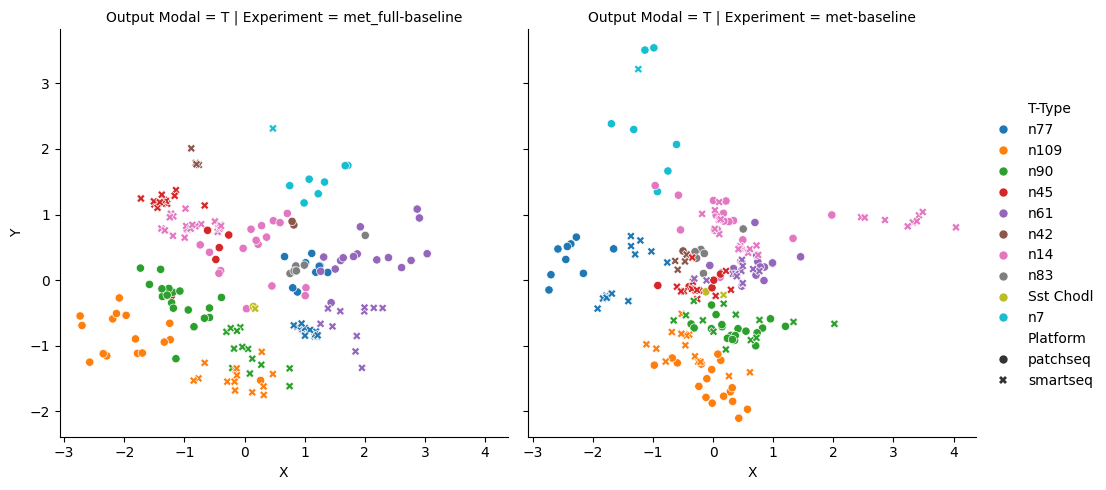

In [ ]:
merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n4")
color_func = np.vectorize(lambda elem: merge_map[elem][-10]) 
data_map = {
    ("Platform", "style", lambda data: data["platform"]),
    ("T-Type", "hue", lambda data: color_func(np.char.strip(data["cluster_label"]))),
    ("Experiment", "col", None)
}
plot = generate_2d_plot(
    {**general_latent["patch+smart"]["baseline"]}, 0, met_data,
    ["met-baseline", "met_full-baseline"], data_map)
# plt.savefig("smartseq_types_latent.pdf")
plt.show()

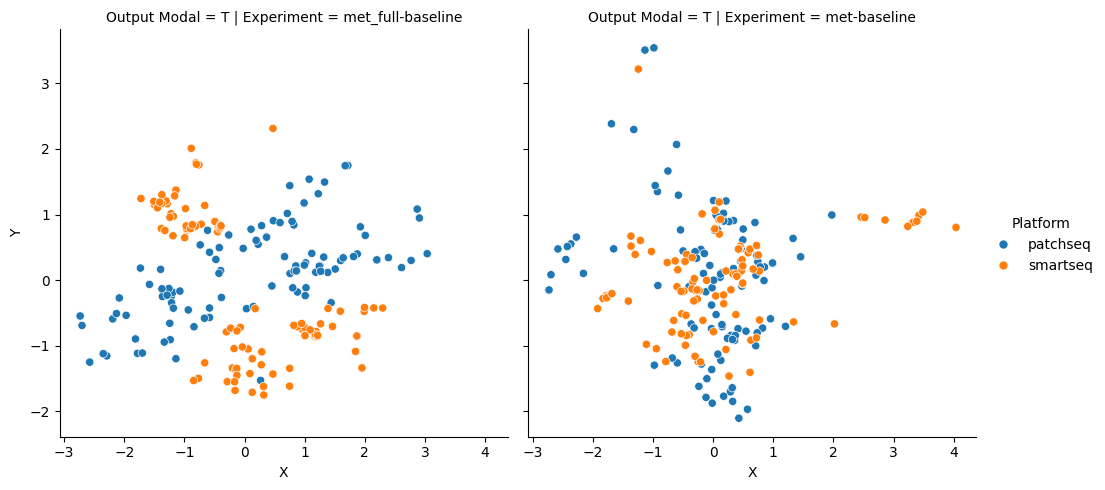

In [12]:
data_map = {
    ("Platform", "hue", lambda data: data["platform"]),
    ("Experiment", "col", None)
}
plot = generate_2d_plot(
    {**general_latent["patch+smart"]["baseline"]}, 0, met_data,
    ["met-baseline", "met_full-baseline"], data_map)
# plt.savefig("smartseq_latent.pdf")
plt.show()

## T-Type Classification

### Random Forest

In [101]:
class TreeClassifier():
    def __init__(self, base_dir, merge, fold, modality):
        base_dir = pathlib.Path(base_dir)
        tree_path = base_dir / "raw_encoders" / str(fold) / str(merge) / f"{modality}.pk"
        if not tree_path.exists():
            raise ValueError(f"No saved tree of modality {modality} found at merge number {merge} and fold {fold}.")
        with open(tree_path, "rb") as target:
            self.tree = pk.load(target)

    def score(self, test_x, test_y):
        return self.tree.score(test_x, test_y)

    def fit(self, train_x, train_y):
        return self

In [109]:
base_dir = pathlib.Path("../results/forest_baselines/120_4_4/models")

specimens = met_data.query(formats = [("logcpm", "pca-ipfx", "arbors")], outputs = ["specimen_id"])["specimen_id"]
merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n4")
mappers = {merge: np.vectorize(lambda elem,merge=merge: merge_map[elem][merge]) 
           for merge in range(len(next(iter(merge_map.values()))) - 1)}
tree_accs = {}
for fold_path in (base_dir / "raw_encoders").iterdir():
    all_train_ids = np.load(fold_path / "train_test_ids.npz")["train"]
    train_ids = specimens[np.isin(np.char.strip(specimens), np.char.strip(all_train_ids))]
    test_ids = specimens[~np.isin(np.char.strip(specimens), np.char.strip(all_train_ids))]
    for (modal, forms) in [("T", ["logcpm"]), ("E", ["pca-ipfx"]), ("M", ["arbors"])]:
        for merge_path in [path for path in fold_path.iterdir() if path.is_dir()]:
            map_id = int(merge_path.name)
            map_func = mappers[map_id]
            print(f"Generating Random Forest Fold {fold_path.name} - {map_id}: {modal} -> T-type             ", end = "\r")
            classifiers = [TreeClassifier(base_dir, map_id, fold_path.name, modal)]
            encoder = lambda form_dict: (torch.flatten(next(iter(form_dict.values())), start_dim = 1),)
            scores = train_classifiers(encoder, classifiers, met_data, train_ids, test_ids, forms, {}, map_func, 6)
            tree_accs.setdefault(modal, {}).setdefault(map_id, []).append(scores[0])
print("\nComplete                                                       ")

Generating Random Forest Fold 5 - 40: M -> T-type               
Complete                                                       


### Clustering

In [7]:
all_accs = {}

In [ ]:
# warnings.filterwarnings("ignore", "Variables are collinear")
specimens = met_data.query(formats = [("logcpm", "pca-ipfx", "arbors")], outputs = ["specimen_id"])["specimen_id"]
merge_map = utils.get_tree_merge_map("../data/meta/tree_Mouse_ALM-VISp_2018.csv", "n4")
mappers = {merge: np.vectorize(lambda elem,merge=merge: merge_map[elem][merge]) 
           for merge in range(len(next(iter(merge_map.values()))) - 1)}
(accs, control) = get_experiment_accuracies({
    "patch": all_experiments["weighted"]["met_et_4x_patch-weighted"],
    "all": all_experiments["weighted"]["met_et_4x-weighted"]}, 
    met_data, specimens, {}, mappers)
all_accs = {**all_accs, **accs}

Generating all - 10: M -> T-type               
Complete                                                       


In [10]:
trees = {"raw": "../results/old_results/forest_baselines/120_4_4/results/raw_encoders", 
         # "3d-fixed": "../data/forest_baselines/results/latent_encoders/met_3d_100-fixed",
        # "10d-full-tree": "../data/forest_baselines/results/latent_encoders/met_10d_100-full",
        # "t_arm-tree": "../data/forest_baselines/results/latent_encoders/t_arm-var",
        # "e_arm-tree": "../data/forest_baselines/results/latent_encoders/e_arm-var",
        # "m_arm-tree": "../data/forest_baselines/results/latent_encoders/m_arm-var",
        }
tree_accs = {}
for (name, exp_path) in trees.items():
    for fold_path in pathlib.Path(exp_path).iterdir():
        fold = int(fold_path.name)
        for modal_path in fold_path.iterdir():
            modal = modal_path.stem
            accs = np.load(modal_path)["arr_0"]
            for (num_merges, acc) in enumerate(accs):
                tree_accs.setdefault(name, {}).setdefault(modal, {}).setdefault(num_merges, []).append(acc)

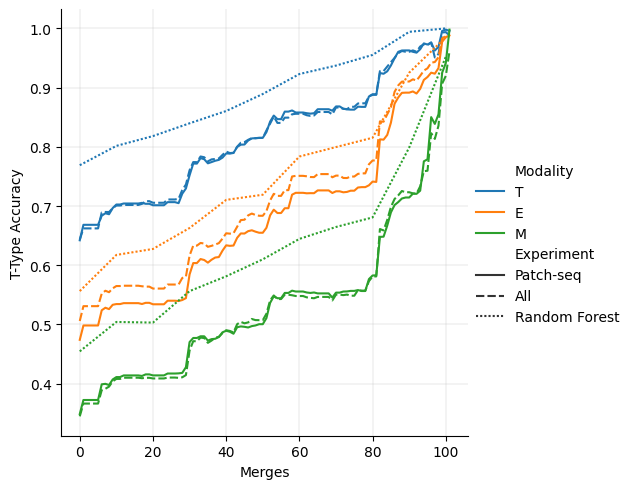

In [12]:
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": [], "Latent Dimension": []}
for (exp_name, modal_dict) in {"Patch-seq": all_accs["patch"], "All": all_accs["all"], "Random Forest": tree_accs["raw"]}.items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend(
                [modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
            results["Latent Dimension"].extend([10 if "3" in exp_name else 3]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

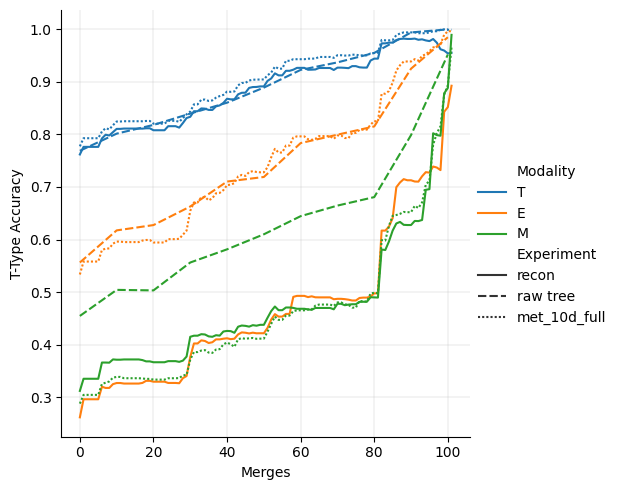

In [ ]:
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": [], "Latent Dimension": []}
for (exp_name, modal_dict) in {"recon": all_accs["recon"], "raw tree": tree_accs["raw"],
                              "met_10d_full": all_accs["met_10d_full"]}.items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend(
                ["M-Forest" if "Forest" in exp_name else modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
            results["Latent Dimension"].extend([10 if "3" in exp_name else 3]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

#### Old Results

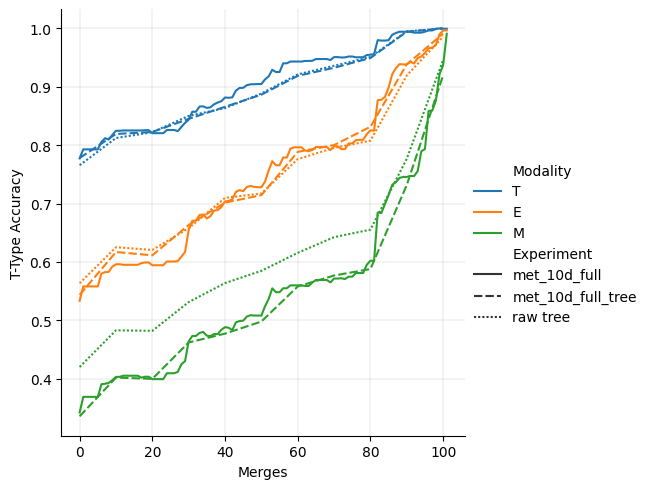

In [337]:
# "met_10d_100-full"
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": [], "Latent Dimension": []}
for (exp_name, modal_dict) in {"met_10d_full": all_accs["met_10d_full"], "met_10d_full_tree": tree_accs["10d-full-tree"], 
                               "raw tree": tree_accs["raw"]}.items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend(
                ["M-Forest" if "Forest" in exp_name else modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
            results["Latent Dimension"].extend([10 if "3" in exp_name else 3]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

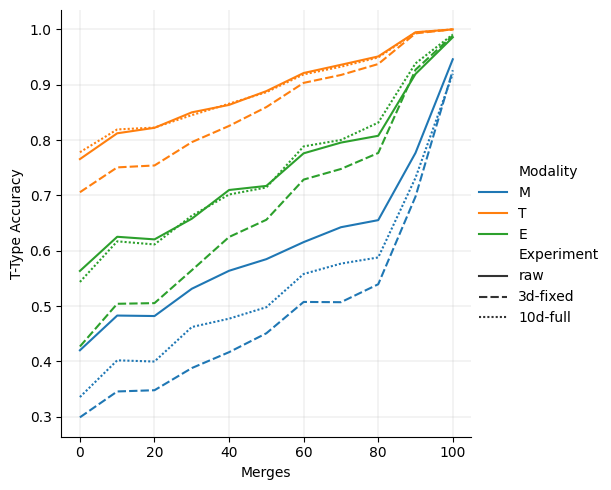

In [313]:
# "met_10d_100-full"
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": [], "Latent Dimension": []}
for (exp_name, modal_dict) in {**tree_accs}.items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend(
                ["M-Forest" if "Forest" in exp_name else modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
            results["Latent Dimension"].extend([10 if "3" in exp_name else 3]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

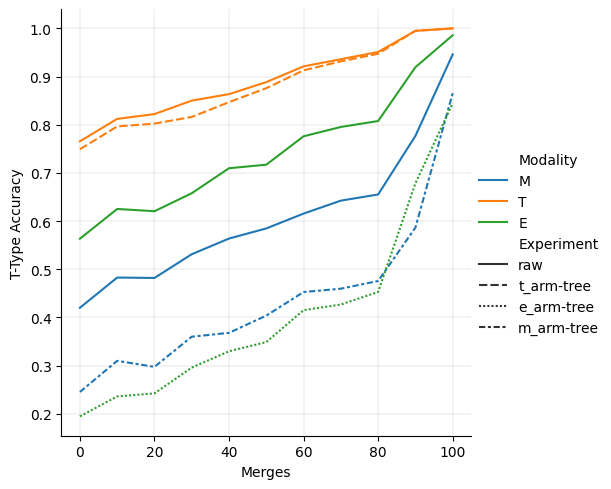

In [344]:
# "met_10d_100-full"
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Experiment": [], "Latent Dimension": []}
for (exp_name, modal_dict) in {**tree_accs}.items():
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend(
                ["M-Forest" if "Forest" in exp_name else modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Experiment"].extend([exp_name]*len(fold_accs))
            results["Latent Dimension"].extend([10 if "3" in exp_name else 3]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Experiment", hue = "Modality",
                   kind = "line", errorbar = None)
for axes_row in plot.axes:
    for axis in axes_row:
        axis.grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

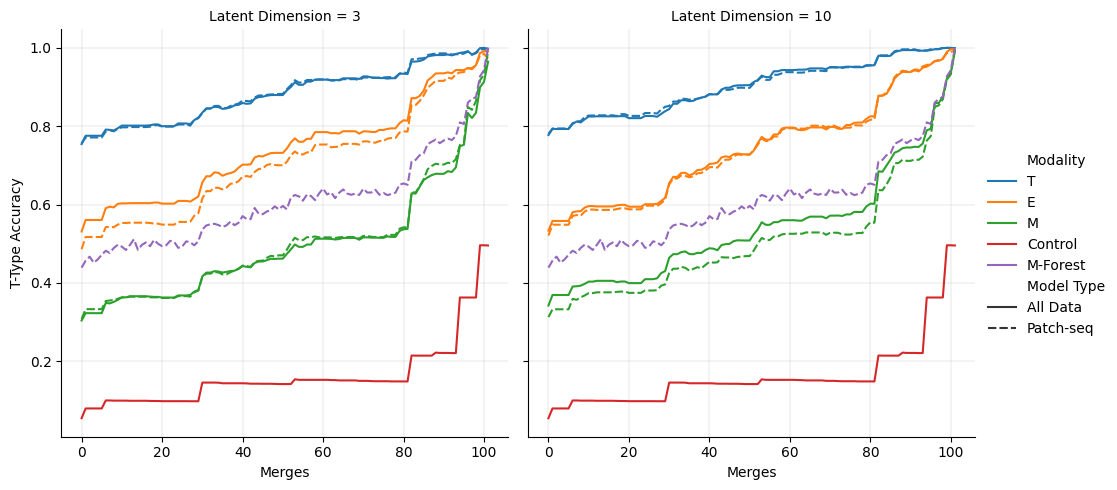

In [283]:
# "met_10d_100-full"
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Model Type": [], "Latent Dimension": []}
for (exp_name, modal_dict) in {**accs, "Control": control, "Control_3": control, "Forest": tree_accs, "Forest_3": tree_accs}.items():
    model_type = "All Data" if ("full" in exp_name or "Control" in exp_name) else "Patch-seq"
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend(
                ["M-Forest" if "Forest" in exp_name else modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Model Type"].extend([model_type]*len(fold_accs))
            results["Latent Dimension"].extend([10 if "3" in exp_name else 3]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Model Type", hue = "Modality", col = "Latent Dimension",
                   kind = "line", errorbar = None)
plot.axes[0][0].grid(linewidth = 0.2)
plot.axes[0][1].grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

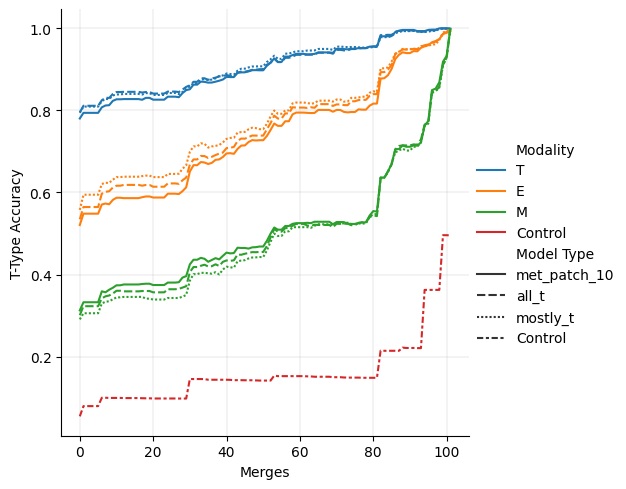

In [301]:
# Focus on coupling with T
results = {"Merges": [], "T-Type Accuracy": [], "Modality": [], "Model Type": []}
for (exp_name, modal_dict) in {**accs, "Control": control}.items():
    model_type = exp_name
    for (modal, merge_dict) in modal_dict.items():
        for (num_merges, fold_accs) in merge_dict.items():
            results["Merges"].extend([num_merges]*len(fold_accs))
            results["T-Type Accuracy"].extend(fold_accs)
            results["Modality"].extend([modal if "Control" not in exp_name else "Control"]*len(fold_accs))
            results["Model Type"].extend([model_type]*len(fold_accs))
plot = sns.relplot(results, x = "Merges", y = "T-Type Accuracy", style = "Model Type", hue = "Modality",
                   kind = "line", errorbar = None)
plot.axes[0][0].grid(linewidth = 0.2)
# plt.savefig("latent_accs_final.pdf")
plt.show()

### Class-Level

In [223]:
specimens = met_data.query(formats = [("logcpm", "pca-ipfx", "arbors")], classes = ["inh"])["specimen_id"]
mappers = {0: np.vectorize(lambda elem: elem.split(" ")[0])}
(class_accs, class_control) = get_experiment_accuracies({
    "met": all_experiments["full"]["met_10d_100-full"],
    "t_arm": all_experiments["var"]["t_arm-var"],
    "e_arm": all_experiments["var"]["e_arm-var"],
    "m_arm": all_experiments["var"]["m_arm-var"]}, 
    met_data, specimens, {}, mappers)

Generating m_arm - 10: M -> T-type             
Complete                                                       


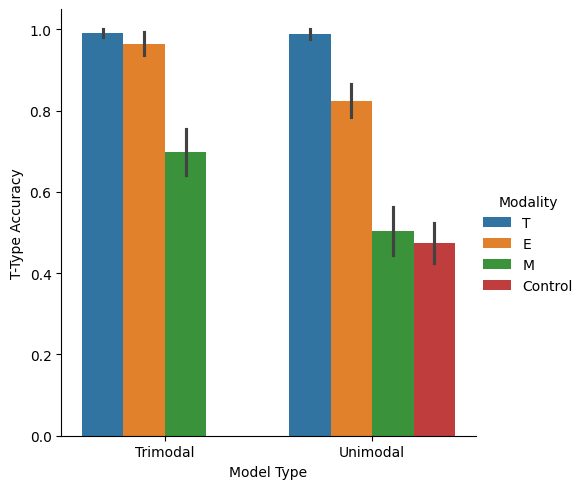

In [224]:
# "met_10d_100-full"
results = {"T-Type Accuracy": [], "Modality": [], "Model Type": []}
for (exp_name, modal_dict) in {**class_accs, "Control": class_control}.items():
    model_type = "Trimodal" if "met" in exp_name else "Bimodal" if "arms" in exp_name else "Unimodal"
    for (modal, score_dict) in modal_dict.items():
        fold_accs = score_dict[0]
        results["T-Type Accuracy"].extend(fold_accs)
        results["Modality"].extend([modal if exp_name != "Control" else "Control"]*len(fold_accs))
        results["Model Type"].extend([model_type]*len(fold_accs))
sns.catplot(results, x = "Model Type", y = "T-Type Accuracy", hue = "Modality", kind = "bar", errorbar = "sd")
plt.show()

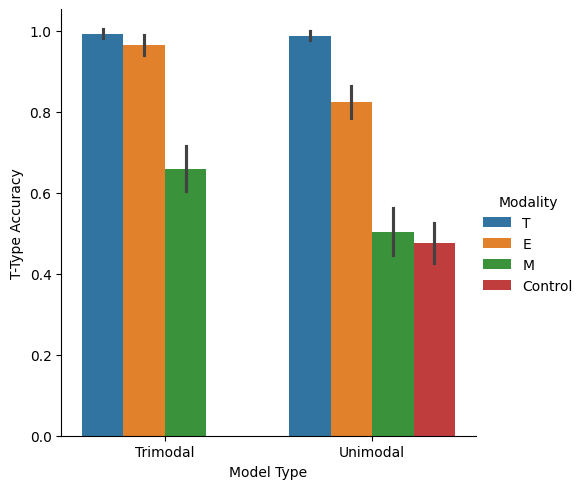

In [222]:
# "met_10d_100-fixed"
results = {"T-Type Accuracy": [], "Modality": [], "Model Type": []}
for (exp_name, modal_dict) in {**class_accs, "Control": class_control}.items():
    model_type = "Trimodal" if "met" in exp_name else "Bimodal" if "arms" in exp_name else "Unimodal"
    for (modal, score_dict) in modal_dict.items():
        fold_accs = score_dict[0]
        results["T-Type Accuracy"].extend(fold_accs)
        results["Modality"].extend([modal if exp_name != "Control" else "Control"]*len(fold_accs))
        results["Model Type"].extend([model_type]*len(fold_accs))
sns.catplot(results, x = "Model Type", y = "T-Type Accuracy", hue = "Modality", kind = "bar", errorbar = "sd")
plt.show()

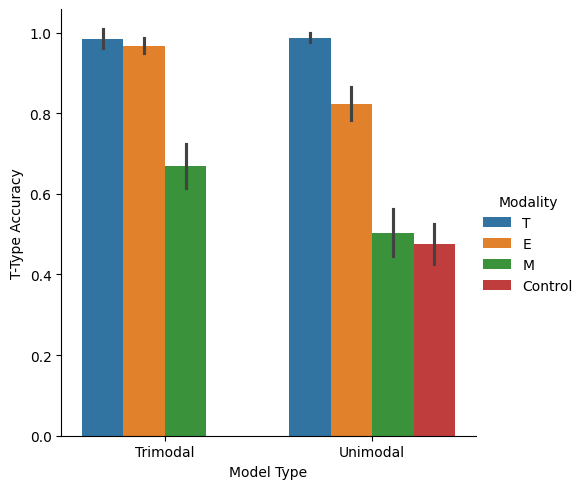

In [213]:
# "met_3d_100-full"
results = {"T-Type Accuracy": [], "Modality": [], "Model Type": []}
for (exp_name, modal_dict) in {**class_accs, "Control": class_control}.items():
    model_type = "Trimodal" if "met" in exp_name else "Bimodal" if "arms" in exp_name else "Unimodal"
    for (modal, score_dict) in modal_dict.items():
        fold_accs = score_dict[0]
        results["T-Type Accuracy"].extend(fold_accs)
        results["Modality"].extend([modal if exp_name != "Control" else "Control"]*len(fold_accs))
        results["Model Type"].extend([model_type]*len(fold_accs))
sns.catplot(results, x = "Model Type", y = "T-Type Accuracy", hue = "Modality", kind = "bar", errorbar = "sd")
plt.show()

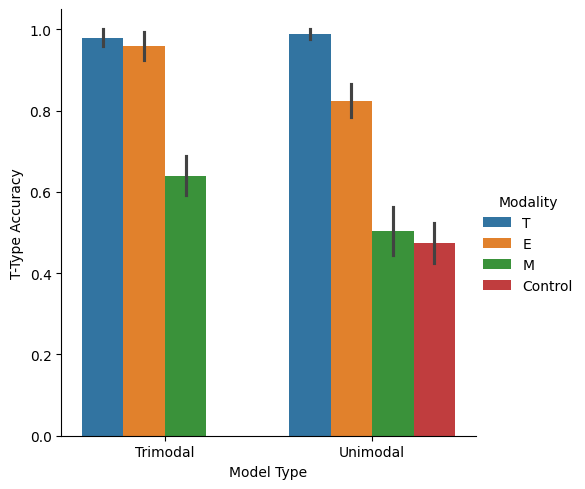

In [210]:
# "met_3d_100-fixed"
results = {"T-Type Accuracy": [], "Modality": [], "Model Type": []}
for (exp_name, modal_dict) in {**class_accs, "Control": class_control}.items():
    model_type = "Trimodal" if "met" in exp_name else "Bimodal" if "arms" in exp_name else "Unimodal"
    for (modal, score_dict) in modal_dict.items():
        fold_accs = score_dict[0]
        results["T-Type Accuracy"].extend(fold_accs)
        results["Modality"].extend([modal if exp_name != "Control" else "Control"]*len(fold_accs))
        results["Model Type"].extend([model_type]*len(fold_accs))
sns.catplot(results, x = "Model Type", y = "T-Type Accuracy", hue = "Modality", kind = "bar", errorbar = "sd")
plt.show()

## Decoder Gradient

In [198]:
model = all_experiments["fixed"]["met_2d_100-fixed"]["folds"][1]["best"]

### Flow Field

In [199]:
out_func = lambda z: model["M"]["dec"](z)["arbors"].detach()
# out_func = lambda z: (z + 1).square().sum(-1, keepdim = True)

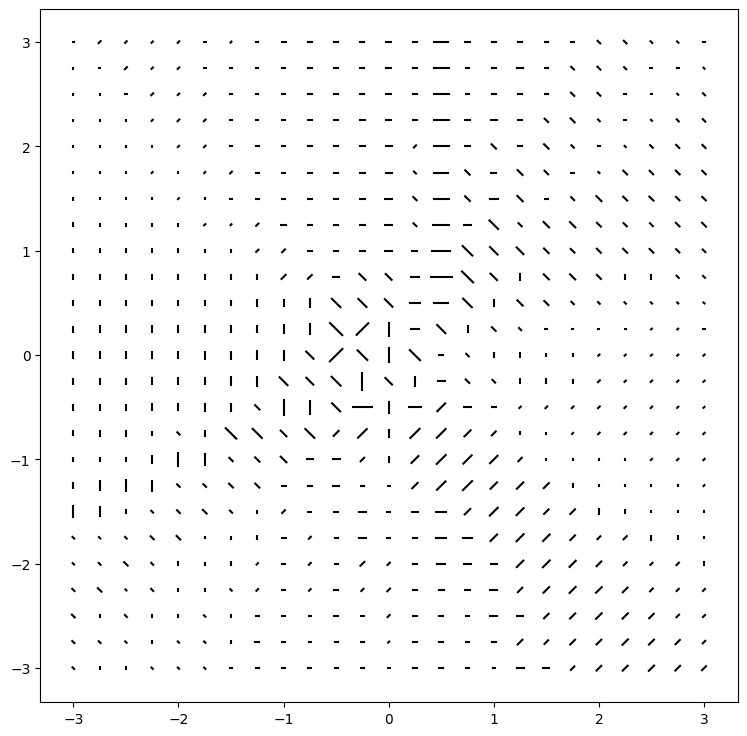

In [195]:
n = 4*6 + 1
delta = 0.1
points = torch.linspace(-3, 3, n)
z_grid = torch.stack(torch.meshgrid(points, points), -1)
displ = torch.asarray([[delta, 0], [0, delta], [delta/2**0.5, delta/2**0.5], [delta/2**0.5, -delta/2**0.5]])
(plus, minus) = (z_grid[:, :, None] + displ[None, None], z_grid[:, :, None] - displ[None, None])
(plus_f, minus_f) = (plus.reshape(4*n**2, 2), minus.reshape(4*n**2, 2))
(output_plus, output_minus) = (out_func(plus_f.float()), out_func(minus_f.float()))
grad = (output_plus - output_minus) / (2*delta)
combined = abs(grad).reshape(n, n, 4, -1).sum(-1)
(max_val, max_dir) = torch.max(combined, -1)
(max_dir, max_val) = (max_dir.reshape(n, n), max_val.reshape(n, n))
max_val = max_val / max_val.max()

lines = displ
plt.figure(figsize = (9, 9))
for (coords, row_dirs, row_vals) in zip(z_grid, max_dir, max_val):
    for (yx, dir, val) in zip(coords, row_dirs, row_vals):
        ((py_1, px_1), (py_2, px_2)) = (yx + lines[dir]*val, yx - lines[dir]*val)
        plt.plot([px_1, px_2], [py_1, py_2], color = "black")
# plt.savefig("gradient_map.pdf")
plt.show()

### Jacobian

In [44]:
n = 62
points = torch.linspace(-3, 3, n)
z_grid = torch.stack(torch.meshgrid(points, points), -1)
z_grid.requires_grad_()
grad_mags = torch.zeros_like(z_grid[..., 0])
for (i, y_vec) in enumerate(z_grid):
    for (j, xy) in enumerate(y_vec):
        print((i, j), end = "\r")
        output = model["E"]["dec"](xy[None])["pca-ipfx"][0]
        cuml = 0
        for vec in torch.eye(82):
            output.backward(vec, retain_graph = True)
            cuml = cuml + z_grid.grad[i, j].square().sum()
            z_grid.grad.zero_()
        grad_mags[i, j] = cuml

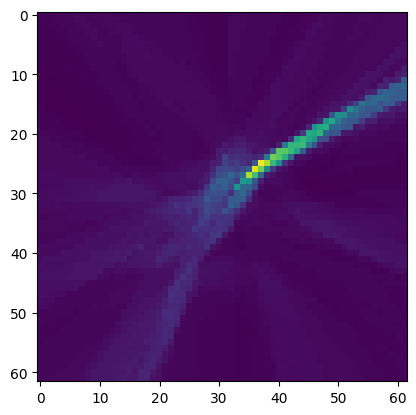

In [45]:
plt.imshow(grad_mags)
plt.show()